# NCF Model for KuaiRec Dataset
## Neural Collaborative Filtering for Recommendation System

This notebook implements the NCF model on the KuaiRec dataset.


In [1]:
# =========
# Load file
# =========
import pandas as pd
import numpy as np

# Load the combined KuaiRec dataset
# If kuairec_combined.csv exists, use it; otherwise use big_matrix.csv
import os
from pathlib import Path

data_dir = Path('../data/kuairec_data')
combined_file = data_dir / 'kuairec_combined.csv'
big_matrix_file = data_dir / 'big_matrix.csv'

if combined_file.exists():
    data_file = str(combined_file)
    print("Using preprocessed kuairec_combined.csv")
elif big_matrix_file.exists():
    data_file = str(big_matrix_file)
    print("Using big_matrix.csv (will process on the fly)")
else:
    raise FileNotFoundError(f"Neither {combined_file} nor {big_matrix_file} found. Please run 00_Download_KuaiRec_Dataset.ipynb first!")

# Load the data
ratings = pd.read_csv(data_file)

# Handle column renaming if needed
if 'user_id' in ratings.columns:
    ratings = ratings.rename(columns={'user_id': 'userId', 'video_id': 'itemId'})
if 'watch_ratio' in ratings.columns and 'rating' not in ratings.columns:
    ratings['rating'] = ratings['watch_ratio']

# Keep only necessary columns
ratings = ratings[['userId', 'itemId', 'rating']]

print("Data loaded successfully!")
print(f"Total interactions: {len(ratings)}")
print(f"Columns: {ratings.columns.tolist()}")


Using preprocessed kuairec_combined.csv
Data loaded successfully!
Total interactions: 12530806
Columns: ['userId', 'itemId', 'rating']


In [2]:
# =========
# Data info
# =========
print("Dataset shape:", ratings.shape)
print("\nFirst few rows:")
print(ratings.head(10))

print("\nData types:")
print(ratings.dtypes)

print("\nBasic statistics:")
print(ratings.describe())

print("\n" + "="*50)
print("Dataset Summary:")
print("="*50)
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print(f"Total interactions: {len(ratings)}")

print("\nRating distribution:")
print(ratings['rating'].value_counts().sort_index().head(20))

# Average ratings
user_avg = ratings.groupby('userId')['rating'].mean()
item_avg = ratings.groupby('itemId')['rating'].mean()

print(f"\nAverage rating per user: {user_avg.mean():.3f}")
print(f"Average rating per item: {item_avg.mean():.3f}")

# Ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
print(f"\nAverage interactions per user: {ratings_per_user.mean():.2f}")
print(f"Min interactions per user: {ratings_per_user.min()}")
print(f"Max interactions per user: {ratings_per_user.max()}")

# Ratings per item
ratings_per_item = ratings.groupby('itemId')['rating'].count()
print(f"\nAverage interactions per item: {ratings_per_item.mean():.2f}")
print(f"Min interactions per item: {ratings_per_item.min()}")
print(f"Max interactions per item: {ratings_per_item.max()}")


Dataset shape: (12530806, 3)

First few rows:
   userId  itemId    rating
0       0    3649  1.273397
1       0    9598  1.244082
2       0    5262  0.107613
3       0    1963  0.089885
4       0    8234  0.078000
5       0    8228  1.572295
6       0    6789  0.175398
7       0    6812  2.212062
8       0     183  0.130492
9       0     169  1.406266

Data types:
userId      int64
itemId      int64
rating    float64
dtype: object

Basic statistics:
             userId        itemId        rating
count  1.253081e+07  1.253081e+07  1.253081e+07
mean   3.574377e+03  5.057748e+03  9.445059e-01
std    2.067008e+03  3.089868e+03  1.674601e+00
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.788000e+03  2.387000e+03  3.148246e-01
50%    3.578000e+03  4.822000e+03  7.234710e-01
75%    5.343750e+03  7.600000e+03  1.177644e+00
max    7.175000e+03  1.072700e+04  5.734571e+02

Dataset Summary:
Unique users: 7176
Unique items: 10728
Total interactions: 12530806

Rating distribution:
rating

In [3]:
# =============
# Preprocessing
# =============
from sklearn.preprocessing import MinMaxScaler

# Filter items with minimum number of ratings
min_item_ratings = 1  # KuaiRec is fully observed, but we can still filter if needed
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings to 0-1 range
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create user and item encodings (map to continuous indices starting from 0)
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

# Apply encoding
ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

# Get dimensions
num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")

# Convert ratings to float32 for better performance
ratings['rating'] = ratings['rating'].values.astype(np.float32)

print("\nPreprocessing complete!")
print(ratings.head())


After filtering items with < 1 ratings:
Remaining interactions: 12530806
Unique users: 7176
Unique items: 10728

Encoded dataset:
Number of users: 7176
Number of items: 10728

Preprocessing complete!
   userId  itemId    rating  user  item
0       0    3649  0.002221     0     0
1       0    9598  0.002169     0     1
2       0    5262  0.000188     0     2
3       0    1963  0.000157     0     3
4       0    8234  0.000136     0     4


In [4]:
# =============================
# User-wise Train-Test split
# =============================
# This ensures each user has representation in both train and test sets

train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    
    # Shuffle user's data
    user_data = user_data.sample(frac=1, random_state=42)
    
    # 80-20 split, but ensure at least 1 sample in each set
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train %: {len(train_df)/(len(train_df)+len(test_df))*100:.1f}%")
print(f"Test %: {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%")


Train-Test split complete!
Train shape: (10021757, 5)
Test shape: (2509049, 5)
Train %: 80.0%
Test %: 20.0%


In [5]:
# ============================
# Prepare Train/Test Arrays
# ============================
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]

y_train = train_df['rating'].values
y_test = test_df['rating'].values

print("Training data prepared!")
print(f"X_train users shape: {X_train[0].shape}")
print(f"X_train items shape: {X_train[1].shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nTest data prepared!")
print(f"X_test users shape: {X_test[0].shape}")
print(f"X_test items shape: {X_test[1].shape}")
print(f"y_test shape: {y_test.shape}")


Training data prepared!
X_train users shape: (10021757,)
X_train items shape: (10021757,)
y_train shape: (10021757,)

Test data prepared!
X_test users shape: (2509049,)
X_test items shape: (2509049,)
y_test shape: (2509049,)


In [6]:
# ===============
# Define NCF Model
# ===============
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.models import Model

# Hyperparameters
embedding_size = 32

# Input layers
user_input = Input(shape=(1,), name="user_input")
item_input = Input(shape=(1,), name="item_input")

# Embedding layers
user_embedding = Embedding(num_users, embedding_size, embeddings_initializer="he_normal", name="user_embedding")(user_input)
item_embedding = Embedding(num_items, embedding_size, embeddings_initializer="he_normal", name="item_embedding")(item_input)

# Flatten embeddings
user_vec = Flatten()(user_embedding)
item_vec = Flatten()(item_embedding)

# Concatenate user and item vectors
concat = Concatenate()([user_vec, item_vec])

# Deep neural network layers
dense = Dense(256, activation='relu')(concat)
dense = BatchNormalization()(dense)
dense = Dropout(0.5)(dense)

dense = Dense(128, activation='relu')(dense)
dense = BatchNormalization()(dense)
dense = Dropout(0.4)(dense)

dense = Dense(64, activation='relu')(dense)
dense = BatchNormalization()(dense)

# Output layer (sigmoid for 0-1 normalized ratings)
output = Dense(1, activation='sigmoid', name="output")(dense)

# Create model
model = Model(inputs=[user_input, item_input], outputs=output)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model architecture:")
model.summary()


Model architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    229,632 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │    343,296 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     16,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 632,577 (2.41 MB)

 Trainable params: 631,681 (2.41 MB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
# ==============
# Train Model
# ==============

# Callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("ncf_kuairec_best_model.keras", save_best_only=True)
]

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 980s 25ms/step - loss: 5.5815e-04 - mae: 0.0033 - val_loss: 8.4152e-06 - val_mae: 9.2358e-04
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 751s 19ms/step - loss: 7.8556e-06 - mae: 9.2818e-04 - val_loss: 9.3195e-06 - val_mae: 9.4107e-04
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 1203s 31ms/step - loss: 7.8297e-06 - mae: 9.2303e-04 - val_loss: 1.1139e-05 - val_mae: 9.1078e-04
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 1211s 31ms/step - loss: 7.8236e-06 - mae: 9.2114e-04 - val_loss: 1.1674e-05 - val_mae: 9.0557e-04

Training complete!


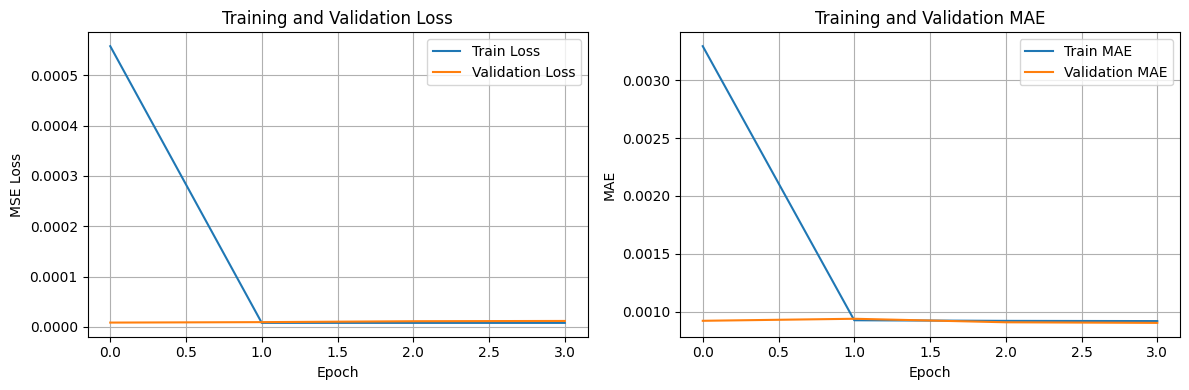

In [8]:
# ====================
# Plot Training History
# ====================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [9]:
# ===========================
# Evaluate on Test Data
# ===========================
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

y_pred = model.predict(X_test, verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*50)

# Save metrics to file
metrics_text = (
    f"NCF Model Evaluation - KuaiRec Dataset\n"
    f"=====================================\n"
    f"Test Loss (MSE): {test_loss:.4f}\n"
    f"Test MAE: {test_mae:.4f}\n"
    f"Test RMSE: {rmse:.4f}\n"
    f"\n"
    f"Dataset Info:\n"
    f"- Total users: {num_users}\n"
    f"- Total items: {num_items}\n"
    f"- Training samples: {len(train_df)}\n"
    f"- Test samples: {len(test_df)}\n"
)

with open("../results/metrics_kuairec.txt", "w") as f:
    f.write(metrics_text)

print("\nMetrics saved to: ../results/metrics_kuairec.txt")


78408/78408 ━━━━━━━━━━━━━━━━━━━━ 355s 5ms/step - loss: 8.4151e-06 - mae: 9.2358e-04

MODEL EVALUATION METRICS
Test Loss (MSE): 0.0000
Test MAE: 0.0009
Test RMSE: 0.0029

Metrics saved to: ../results/metrics_kuairec.txt


In [10]:
# ===============
# Recommender Function
# ===============
def recommend_items(user_id_original, model, user2user_encoded, item2item_encoded, 
                   itemencoded2item, train_df, num_items, top_n=10):
    """
    Recommend top N items for a given user
    """
    # Check if user exists
    if user_id_original not in user2user_encoded:
        print(f"User {user_id_original} not found in the dataset!")
        return []
    
    # Encode user
    user_enc = user2user_encoded[user_id_original]
    
    # All encoded items
    all_item_ids = np.arange(num_items)
    
    # Items the user has already rated in training
    items_rated = train_df[train_df['user'] == user_enc]['item'].values
    
    # Candidate items (unseen by user)
    items_to_predict = np.setdiff1d(all_item_ids, items_rated)
    
    if len(items_to_predict) == 0:
        print(f"User {user_id_original} has already rated all items!")
        return []
    
    # Prepare input arrays
    user_array = np.full(len(items_to_predict), user_enc)
    
    # Predict scores
    preds = model.predict([user_array, items_to_predict], verbose=0).flatten()
    
    # Sort by predicted score
    top_indices = items_to_predict[np.argsort(preds)[::-1][:top_n]]
    top_scores = preds[np.argsort(preds)[::-1][:top_n]]
    
    # Map back to original item IDs
    recommendations = []
    for item_enc, score in zip(top_indices, top_scores):
        item_id_original = itemencoded2item[item_enc]
        # Convert score back to original scale
        score_original = scaler.inverse_transform([[score]])[0][0]
        recommendations.append((item_id_original, score, score_original))
    
    return recommendations

print("Recommender function defined!")


Recommender function defined!


In [11]:
# ===============================
# Generate Recommendations
# ===============================
# Let's get recommendations for a random user

# Pick a random user from the dataset
sample_user = np.random.choice(list(user2user_encoded.keys()))

print(f"Generating recommendations for User {sample_user}")
print("="*50)

# Get user's existing ratings from training set
user_enc = user2user_encoded[sample_user]
user_history = train_df[train_df['user'] == user_enc][['itemId', 'rating']].head(10)

print(f"\nUser {sample_user}'s rating history (sample):")
if len(user_history) > 0:
    for idx, row in user_history.iterrows():
        rating_original = scaler.inverse_transform([[row['rating']]])[0][0]
        print(f"  Item {row['itemId']}: Rating {rating_original:.2f}")
else:
    print("  No rating history in training set")

# Generate recommendations
recommendations = recommend_items(
    user_id_original=sample_user,
    model=model,
    user2user_encoded=user2user_encoded,
    item2item_encoded=item2item_encoded,
    itemencoded2item=itemencoded2item,
    train_df=train_df,
    num_items=num_items,
    top_n=10
)

print(f"\nTop 10 Recommended Items for User {sample_user}:")
print("="*50)
for i, (item_id, score_scaled, score_original) in enumerate(recommendations, 1):
    print(f"{i:2d}. Item {item_id:4d} | Predicted Rating: {score_original:.2f} (scaled: {score_scaled:.3f})")


Generating recommendations for User 4495

User 4495's rating history (sample):
  Item 4338.0: Rating 0.66
  Item 6808.0: Rating 1.15
  Item 2319.0: Rating 1.24
  Item 5302.0: Rating 1.69
  Item 4443.0: Rating 0.93
  Item 2789.0: Rating 0.92
  Item 815.0: Rating 0.12
  Item 3042.0: Rating 0.65
  Item 2920.0: Rating 1.40
  Item 4008.0: Rating 1.17

Top 10 Recommended Items for User 4495:
 1. Item 7445 | Predicted Rating: 11.16 (scaled: 0.019)
 2. Item 3400 | Predicted Rating: 3.21 (scaled: 0.006)
 3. Item 9192 | Predicted Rating: 2.95 (scaled: 0.005)
 4. Item 10017 | Predicted Rating: 2.94 (scaled: 0.005)
 5. Item 1654 | Predicted Rating: 2.78 (scaled: 0.005)
 6. Item 3367 | Predicted Rating: 2.77 (scaled: 0.005)
 7. Item 6463 | Predicted Rating: 2.75 (scaled: 0.005)
 8. Item 3401 | Predicted Rating: 2.71 (scaled: 0.005)
 9. Item 4374 | Predicted Rating: 2.66 (scaled: 0.005)
10. Item 3306 | Predicted Rating: 2.65 (scaled: 0.005)


In [12]:
# ===============================
# Model Summary and Information
# ===============================
print("\n" + "="*60)
print("NCF MODEL SUMMARY")
print("="*60)
print(f"Dataset: KuaiRec Dataset")
print(f"Total Users: {num_users}")
print(f"Total Items: {num_items}")
print(f"Total Interactions: {len(ratings)}")
print(f"\nTraining Samples: {len(train_df)}")
print(f"Test Samples: {len(test_df)}")
print(f"\nEmbedding Size: {embedding_size}")
print(f"\nTest MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print("="*60)
print("\nModel saved as: ncf_kuairec_best_model.keras")
print("Metrics saved as: ../results/metrics_kuairec.txt")



NCF MODEL SUMMARY
Dataset: KuaiRec Dataset
Total Users: 7176
Total Items: 10728
Total Interactions: 12530806

Training Samples: 10021757
Test Samples: 2509049

Embedding Size: 32

Test MSE: 0.0000
Test MAE: 0.0009
Test RMSE: 0.0029

Model saved as: ncf_kuairec_best_model.keras
Metrics saved as: ../results/metrics_kuairec.txt
